# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [2]:
df = pd.read_csv('data/nndb_flat.csv')
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   str    
 2   ShortDescrip      8618 non-null   str    
 3   Descrip           8618 non-null   str    
 4   CommonName        1063 non-null   str    
 5   MfgName           1560 non-null   str    
 6   ScientificName    732 non-null    str    
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64
 17  VitE_m

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

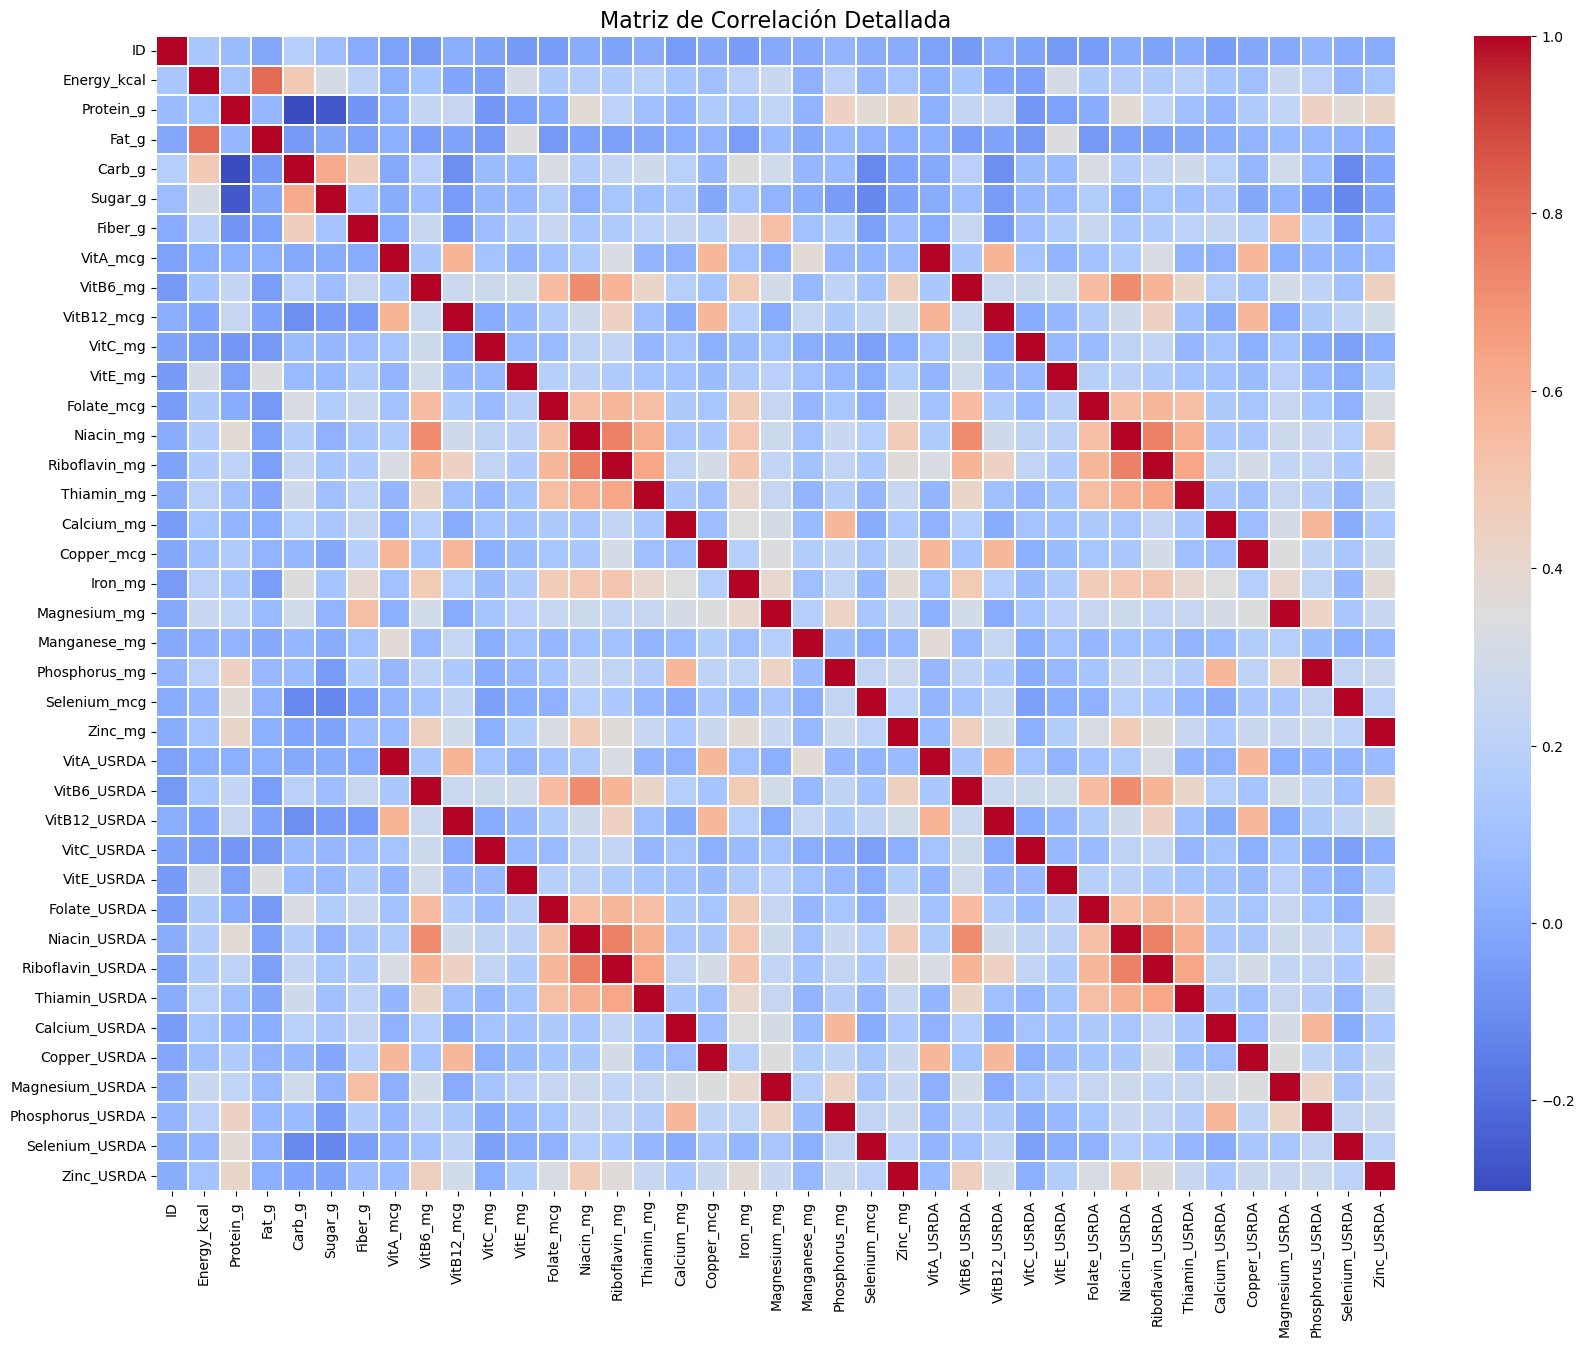

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuramos un tamaño de figura grande (ej: 20x15 pulgadas)
plt.figure(figsize=(20, 15))

# 2. Creamos el heatmap con etiquetas legibles
sns.heatmap(
    df.corr(numeric_only=True), 
    annot=False,          # Si pones True, los números se verán muy pequeños
    cmap='coolwarm', 
    linewidths=0.1,      # Añade una línea fina entre cuadros para separarlos
    xticklabels=True,    # Fuerza a mostrar todas las etiquetas en el eje X
    yticklabels=True     # Fuerza a mostrar todas las etiquetas en el eje Y
)

# 3. Rotamos las etiquetas para que no se pisen
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.title('Matriz de Correlación Detallada', fontsize=16)
plt.show()

Mejor ignorar porque son proporcionales a la propia cantidad de cada micronutriente. Es mejor que el PCA no tenga redundancias. 

In [4]:
# Filtramos para quedarnos solo con las columnas que NO contienen 'USRDA'
cols_to_keep = [c for c in df.columns if not c.endswith('_USRDA')]
df = df[cols_to_keep]

### Variables no numéricas
Elimina las variables de texto del dataset

In [5]:
df_numeric = df.drop(columns=['FoodGroup', 'ShortDescrip', 'Descrip','CommonName','MfgName', 'ScientificName', 'ID' ])
df_numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy_kcal    8618 non-null   float64
 1   Protein_g      8618 non-null   float64
 2   Fat_g          8618 non-null   float64
 3   Carb_g         8618 non-null   float64
 4   Sugar_g        8618 non-null   float64
 5   Fiber_g        8618 non-null   float64
 6   VitA_mcg       8618 non-null   float64
 7   VitB6_mg       8618 non-null   float64
 8   VitB12_mcg     8618 non-null   float64
 9   VitC_mg        8618 non-null   float64
 10  VitE_mg        8618 non-null   float64
 11  Folate_mcg     8618 non-null   float64
 12  Niacin_mg      8618 non-null   float64
 13  Riboflavin_mg  8618 non-null   float64
 14  Thiamin_mg     8618 non-null   float64
 15  Calcium_mg     8618 non-null   float64
 16  Copper_mcg     8618 non-null   float64
 17  Iron_mg        8618 non-null   float64
 18  Magnesium_mg   8618

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [6]:
# Aplicamos logaritmo para normalizar distribuciones
df_log = df_numeric.apply(lambda x: np.log(x + 1))

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [7]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [8]:
pca_full = PCA()
pca_full.fit(df_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

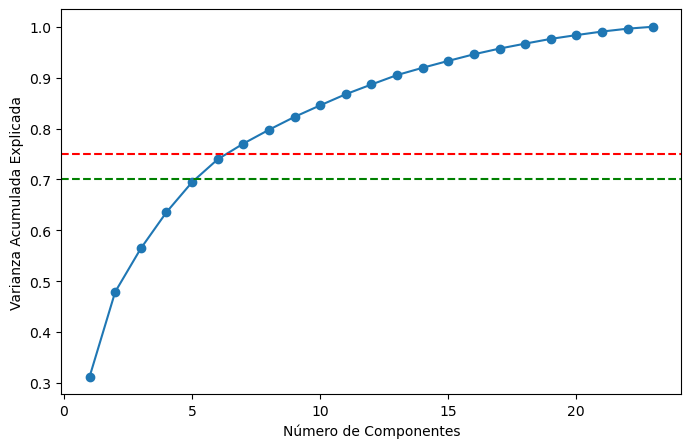

Para un 70-75%, me quedaría con 7 componentes.


In [9]:
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.axhline(y=0.75, color='r', linestyle='--') # Línea de referencia al 75%
plt.axhline(y=0.70, color='g', linestyle='--') # Línea de referencia al 70%
plt.show()

# Respondiendo a la pregunta:
n_components_75 = np.argmax(cumulative_variance >= 0.75) + 1
n_components_70 = np.argmax(cumulative_variance >= 0.70) + 1
print(f"Para un 70-75%, me quedaría con {n_components_75} componentes.")

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [10]:
X = n_components_75 
pca_final = PCA(n_components=X)
df_pca = pca_final.fit_transform(df_scaled)

# Crear DataFrame con los nuevos componentes
df_final = pd.DataFrame(df_pca, columns=[f'PC{i+1}' for i in range(X)])

df_final

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222,0.151252
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613,0.212474
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607,0.441633
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054,0.487040
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876,0.797944
...,...,...,...,...,...,...,...
8613,2.553661,-2.548700,-0.472185,-0.109428,2.716513,0.018570,-0.233604
8614,0.075018,-1.840922,-0.935725,-1.348908,-0.392092,-0.759672,-0.429117
8615,-2.930529,1.664405,1.242070,1.172396,-0.915550,-0.885902,0.980484
8616,1.118895,-0.780834,-0.805126,-1.581838,1.641702,1.090002,-0.871438


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [11]:
# Recuperamos la columna FoodGroup del dataframe original
# Asumiendo que tu dataframe original se llama 'df'
food_groups = df['FoodGroup']

# Ahora ya puedes ejecutar la celda que fallaba:
df_final['FoodGroup'] = food_groups

for i in range(X):
    pc_name = f'PC{i+1}'
    print(f"--- Top 3 Food Groups para {pc_name} ---")
    # Agrupamos por FoodGroup y vemos la media en ese PC
    top_groups = df_final.groupby('FoodGroup')[pc_name].mean().sort_values(ascending=False).head(3)
    print(top_groups)
    print("\n")

--- Top 3 Food Groups para PC1 ---
FoodGroup
Breakfast Cereals        4.020261
Nut and Seed Products    3.120684
Spices and Herbs         2.562117
Name: PC1, dtype: float64


--- Top 3 Food Groups para PC2 ---
FoodGroup
Spices and Herbs         3.647736
Breakfast Cereals        2.748076
Nut and Seed Products    2.267573
Name: PC2, dtype: float64


--- Top 3 Food Groups para PC3 ---
FoodGroup
Fats and Oils            2.333724
Baked Products           1.727793
Nut and Seed Products    1.241486
Name: PC3, dtype: float64


--- Top 3 Food Groups para PC4 ---
FoodGroup
Breakfast Cereals    2.265027
Fats and Oils        1.045026
Beverages            0.545486
Name: PC4, dtype: float64


--- Top 3 Food Groups para PC5 ---
FoodGroup
Fats and Oils             2.634166
Dairy and Egg Products    1.555680
Baby Foods                0.929960
Name: PC5, dtype: float64


--- Top 3 Food Groups para PC6 ---
FoodGroup
Fats and Oils            2.054032
Nut and Seed Products    1.762298
Spices and Herbs     